# PR-4: Linear Probe Qualitative Evaluation

This notebook evaluates trained linear probes to understand how well each transformer layer's residual stream encodes interpretable time series properties.

## What's being probed

| Feature | Type | Baseline |
|---------|------|----------|
| `slope` | Regression (R²) | 0.0 |
| `log_noise_var` | Regression (R²) | 0.0 |
| `phase_cos` | Regression (R²) | 0.0 |
| `phase_sin` | Regression (R²) | 0.0 |
| `period_idx` | Classification (accuracy) | 0.125 (8-class chance) |

## Running this notebook

**Option A** — Use pre-computed results from `train_probes.py`:
```bash
python -m experiments.mech_interp.block1_probing.train_probes \
    --moiraie-ckpt /path/to/moiraie.ckpt \
    --moiraic-ckpt /path/to/moiraic.ckpt
```

**Option B** — Run end-to-end in this notebook with tiny in-memory models (demo mode, random weights).

In [1]:
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA

# Repo root on sys.path
REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from experiments.mech_interp.lib import generate_dataset
from experiments.mech_interp.block1_probing.train_probes import (
    extract_activations, run_probes_for_model,
    REGRESSION_FEATURES, CLASSIFICATION_FEATURES,
    PATCH_SIZE, CONTEXT_PATCHES, PRED_PATCHES,
)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results')
MOIRAIE_JSON = os.path.join(RESULTS_DIR, 'moiraie.json')
MOIRAIC_JSON = os.path.join(RESULTS_DIR, 'moiraic.json')

print(f"Results dir: {RESULTS_DIR}")
print(f"moiraie.json exists: {os.path.exists(MOIRAIE_JSON)}")
print(f"moiraic.json exists: {os.path.exists(MOIRAIC_JSON)}")
device = 'cuda:7'

Results dir: /srv/disk00/ctadler/uni2ts/experiments/mech_interp/block1_probing/results
moiraie.json exists: False
moiraic.json exists: False


## Load or generate probe results

In [3]:
def load_results(path):
    with open(path) as f:
        raw = json.load(f)
    # Convert string layer keys to ints
    return {feat: {int(k): v for k, v in layers.items()} for feat, layers in raw.items()}


USE_REAL_RESULTS = os.path.exists(MOIRAIE_JSON) and os.path.exists(MOIRAIC_JSON)

if USE_REAL_RESULTS:
    print("Loading pre-computed probe results.")
    results = {
        'moiraie': load_results(MOIRAIE_JSON),
        'moiraic': load_results(MOIRAIC_JSON),
    }
else:
    print("No pre-computed results found. Running with tiny in-memory models (DEMO MODE — random weights).")
    from uni2ts.model.moiraie.module import MoiraieModule
    from uni2ts.model.moiraic.module import MoiraicModule

    _TINY = dict(d_model=64, d_ff=128, num_layers=4, patch_size=PATCH_SIZE,
                 max_seq_len=64, attn_dropout_p=0., dropout_p=0.)
    module_e = MoiraieModule.from_pretrained("/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraie/gift_eval_pretrain_weighted/moiraie_training_7/HF_checkpoints/last").eval().to(device)
    module_c = MoiraicModule.from_pretrained("/srv/disk00/ctadler/uni2ts/outputs/pretrain/moiraic/gift_eval_pretrain_weighted/moiraic_training_11/HF_checkpoints/last").eval().to(device)

    dataset = generate_dataset(n=500, seed=42)
    rng = np.random.default_rng(42)
    idx = rng.permutation(500)
    train_idx, val_idx = idx[:400], idx[400:]

    print("Fitting probes on moiraie...")
    results = {
        'moiraie': run_probes_for_model(module_e, dataset, train_idx, val_idx, batch_size=32, device=device),
        'moiraic': run_probes_for_model(module_c, dataset, train_idx, val_idx, batch_size=32, device=device),
    }
    print("Done.")

# Determine number of layers from results
num_layers = max(len(v) for r in results.values() for v in r.values())
print(f"\nNum layers: {num_layers}")
print("Features:", list(next(iter(results.values())).keys()))

No pre-computed results found. Running with tiny in-memory models (DEMO MODE — random weights).
Loading weights from local directory
Loading weights from local directory
Fitting probes on moiraie...
  Extracting train activations (400 examples)...
  Extracting val activations (100 examples)...


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.29704e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.08114e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.21968e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.64017e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    slope: best layer score = 0.9368


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.29704e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.08114e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=2.21968e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.64017e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    log_noise_var: best layer score = 0.7911


...

    log_noise_var: best layer score = 0.8137


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.41996e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.36535e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.68722e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.71199e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    phase_cos: best layer score = 0.4829


/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.41996e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.36535e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.68722e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
/srv/disk00/ctadler/uni2ts/venv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:250: LinAlgWarning: Ill-conditioned matrix (rcond=3.71199e-08): result may not be accurate.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a

    phase_sin: best layer score = 0.6006
    period_idx: best layer score = 0.9500
Done.

Num layers: 8
Features: ['slope', 'log_noise_var', 'phase_cos', 'phase_sin', 'period_idx']


## Layer-by-layer probe scores

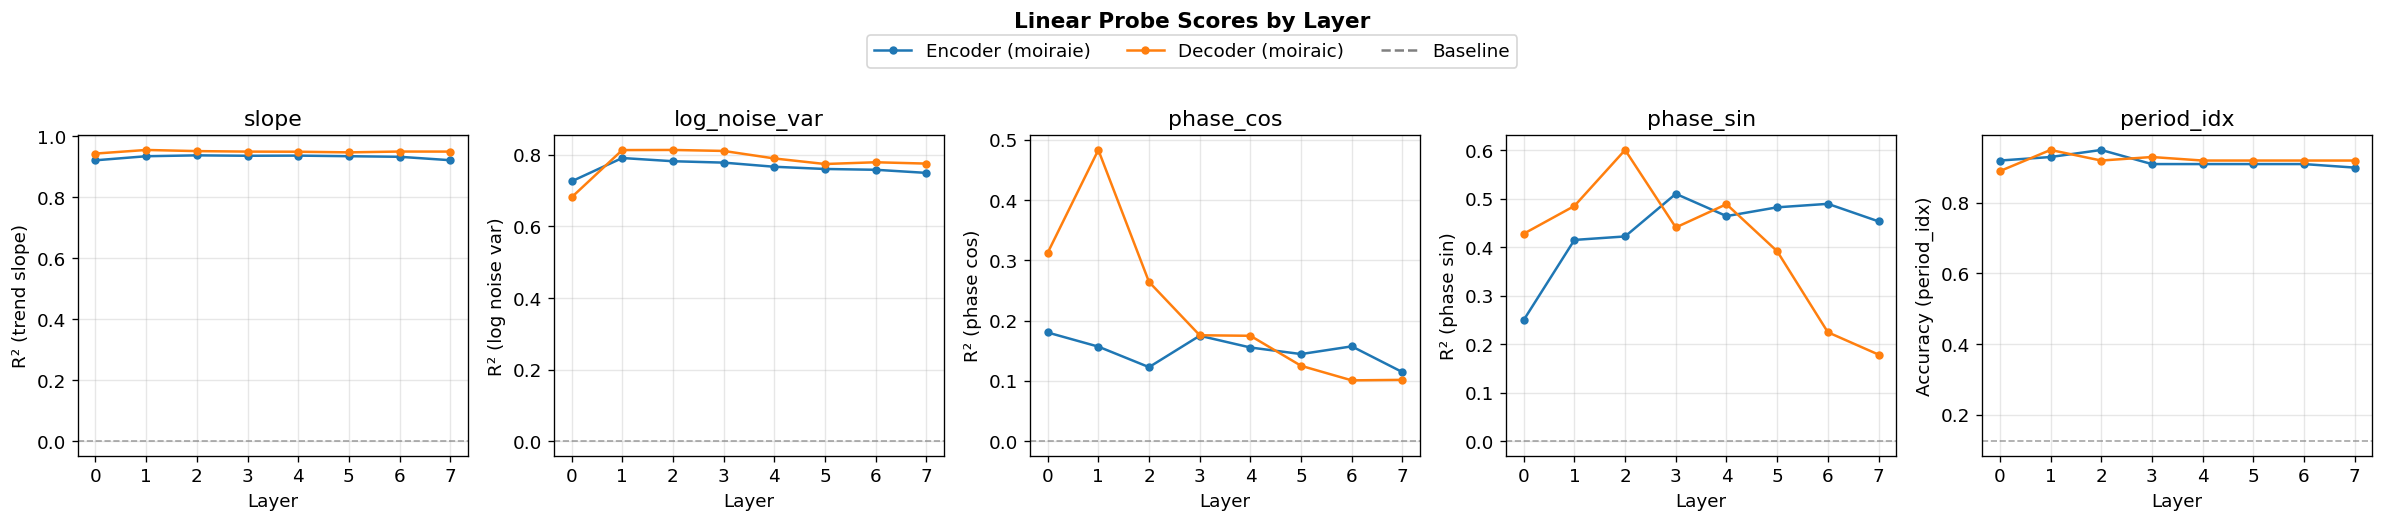

In [4]:
# Baselines
BASELINES = {
    'slope': 0.0,
    'log_noise_var': 0.0,
    'phase_cos': 0.0,
    'phase_sin': 0.0,
    'period_idx': 1.0 / 8,  # 8-class chance accuracy
}

SCORE_LABELS = {
    'slope': 'R² (trend slope)',
    'log_noise_var': 'R² (log noise var)',
    'phase_cos': 'R² (phase cos)',
    'phase_sin': 'R² (phase sin)',
    'period_idx': 'Accuracy (period_idx)',
}

MODEL_COLORS = {'moiraie': 'tab:blue', 'moiraic': 'tab:orange'}
MODEL_LABELS = {'moiraie': 'Encoder (moiraie)', 'moiraic': 'Decoder (moiraic)'}

all_features = REGRESSION_FEATURES + CLASSIFICATION_FEATURES
layers = list(range(num_layers))

fig, axes = plt.subplots(1, len(all_features), figsize=(4 * len(all_features), 4), sharey=False)
if len(all_features) == 1:
    axes = [axes]

for ax, feature in zip(axes, all_features):
    baseline = BASELINES.get(feature, 0.0)
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Baseline')

    for model_name, model_results in results.items():
        if feature not in model_results:
            continue
        scores = [model_results[feature][l] for l in layers]
        ax.plot(layers, scores, marker='o', markersize=4,
                color=MODEL_COLORS[model_name], label=MODEL_LABELS[model_name])

    ax.set_xlabel('Layer')
    ax.set_ylabel(SCORE_LABELS.get(feature, feature))
    ax.set_title(feature)
    ax.set_xticks(layers)
    ax.grid(True, alpha=0.3)

# Shared legend
legend_elements = [
    Line2D([0], [0], color=MODEL_COLORS['moiraie'], marker='o', markersize=4, label=MODEL_LABELS['moiraie']),
    Line2D([0], [0], color=MODEL_COLORS['moiraic'], marker='o', markersize=4, label=MODEL_LABELS['moiraic']),
    Line2D([0], [0], color='gray', linestyle='--', label='Baseline'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Linear Probe Scores by Layer', y=1.08, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary table: best layer and peak score per feature × model

In [5]:
rows = []
for feature in all_features:
    for model_name, model_results in results.items():
        if feature not in model_results:
            continue
        layer_scores = model_results[feature]
        best_layer = max(layer_scores, key=layer_scores.get)
        peak_score = layer_scores[best_layer]
        metric = 'accuracy' if feature in CLASSIFICATION_FEATURES else 'R²'
        baseline = BASELINES.get(feature, 0.0)
        rows.append({
            'Feature': feature,
            'Model': MODEL_LABELS[model_name],
            'Metric': metric,
            'Best Layer': best_layer,
            f'Peak {metric.capitalize()}': round(peak_score, 4),
            f'Baseline': round(baseline, 4),
            'Above baseline': peak_score > baseline,
        })

df = pd.DataFrame(rows)
df

,Feature,Model,Metric,Best Layer,Peak R²,Baseline,Above baseline,Peak Accuracy
0,slope,Encoder (moiraie),R²,2,0.9368,0.000,True,NaN
1,slope,Decoder (moiraic),R²,1,0.9545,0.000,True,NaN
2,log_noise_var,Encoder (moiraie),R²,1,0.7911,0.000,True,NaN
3,log_noise_var,Decoder (moiraic),R²,2,0.8137,0.000,True,NaN
4,phase_cos,Encoder (moiraie),R²,0,0.1802,0.000,True,NaN
5,phase_cos,Decoder (moiraic),R²,1,0.4829,0.000,True,NaN
6,phase_sin,Encoder (moiraie),R²,3,0.5101,0.000,True,NaN
7,phase_sin,Decoder (moiraic),R²,2,0.6006,0.000,True,NaN
8,period_idx,Encoder (moiraie),accuracy,2,NaN,0.125,True,0.95
9,period_idx,Decoder (moiraic),accuracy,1,NaN,0.125,True,0.95


## PCA visualization of mean-pooled activations

Shows how the representation space evolves across layers. Each point is one example; color = ground-truth feature value.

In [6]:
# We need actual activations for PCA — load a model
try:
    from uni2ts.model.moiraie.module import MoiraieModule
    from uni2ts.model.moiraic.module import MoiraicModule
    _HAVE_MODELS = True
except ImportError:
    _HAVE_MODELS = False
    print("Cannot import models — skipping PCA section.")

In [7]:
if _HAVE_MODELS:
    # Build tiny model for PCA demo, or use real model if checkpoints available
    _TINY_PCA = dict(d_model=64, d_ff=128, num_layers=num_layers, patch_size=PATCH_SIZE,
                     max_seq_len=64, attn_dropout_p=0., dropout_p=0.)
    pca_module = MoiraieModule(**_TINY_PCA, num_predict_token=1).eval()

    pca_dataset = generate_dataset(n=200, seed=7)
    print(f"PCA dataset: {pca_dataset['series'].shape}")

    print("Extracting activations for PCA...")
    pca_acts = extract_activations(pca_module, pca_dataset['series'], batch_size=32)
    print("Done.")

PCA dataset: (200, 576)
Extracting activations for PCA...
Done.


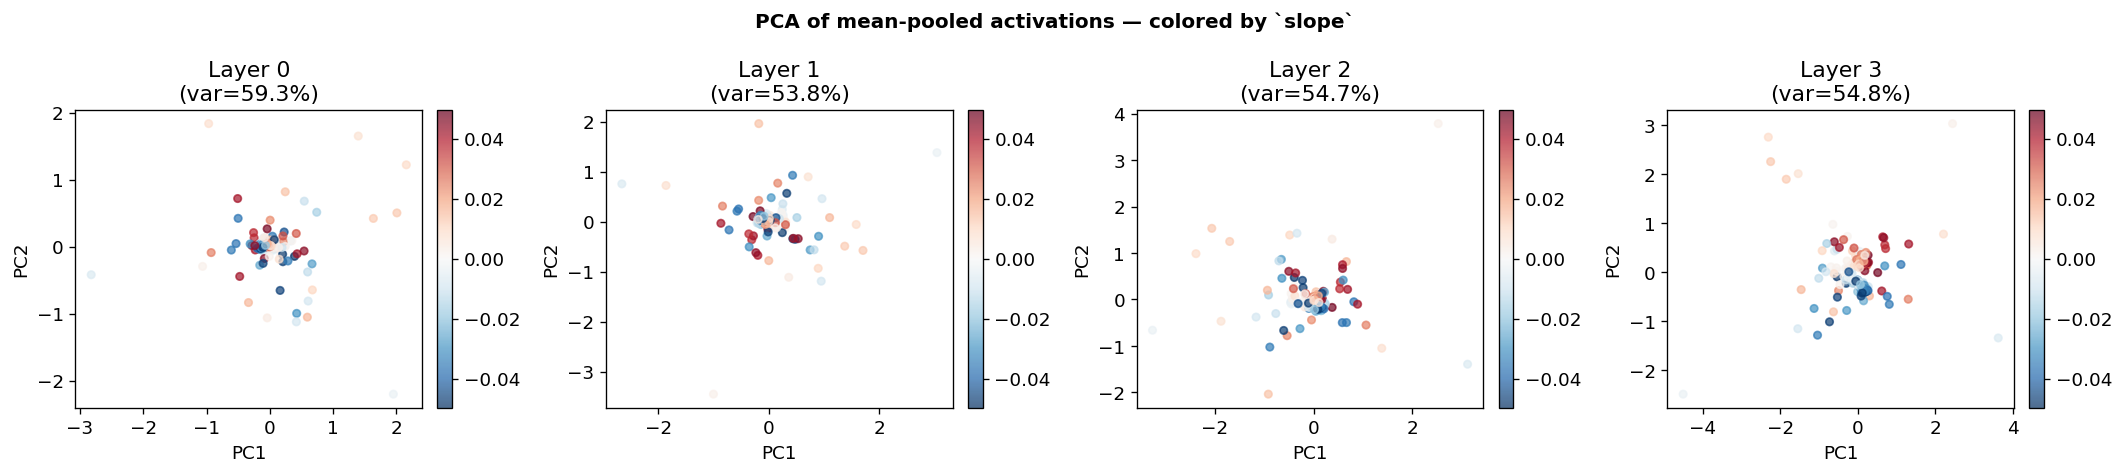

/tmp/ipykernel_3175845/1612445606.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3175845/1612445606.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3175845/1612445606.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('tab10')
/tmp/ipykernel_3175845/1612445606.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and 

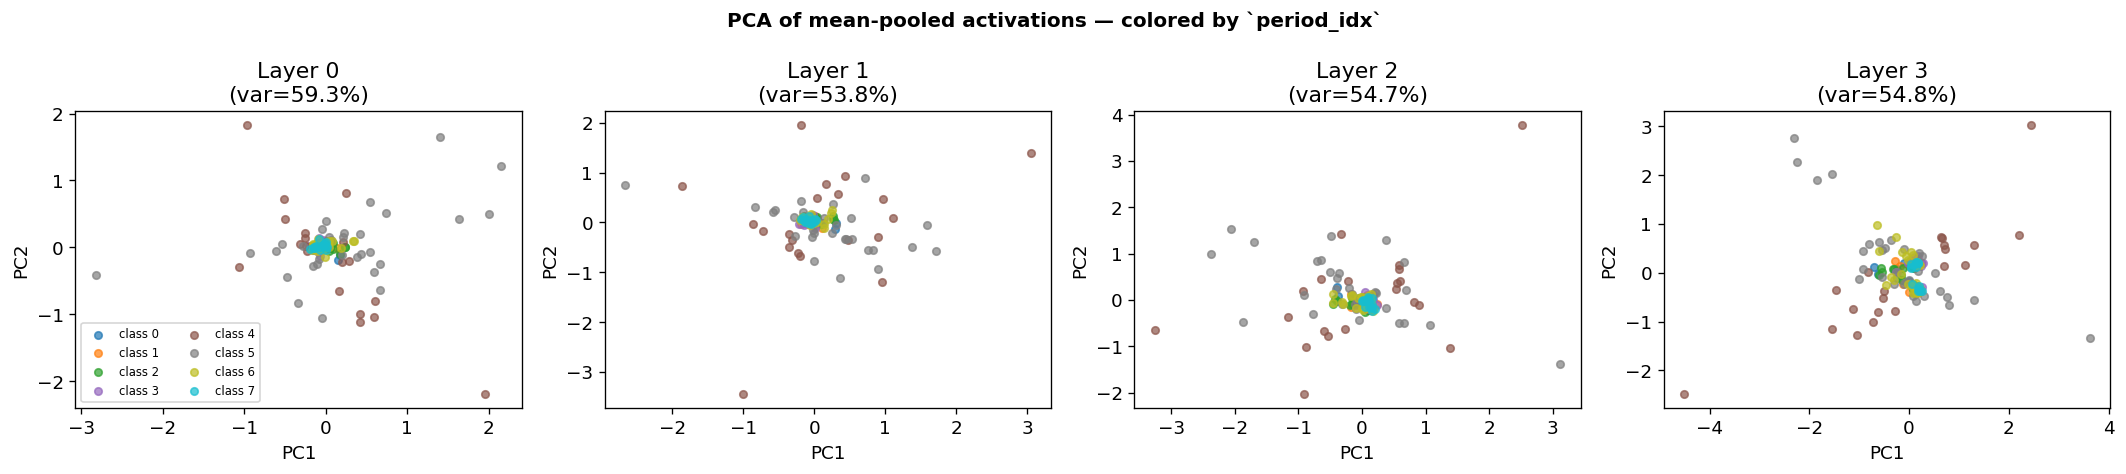

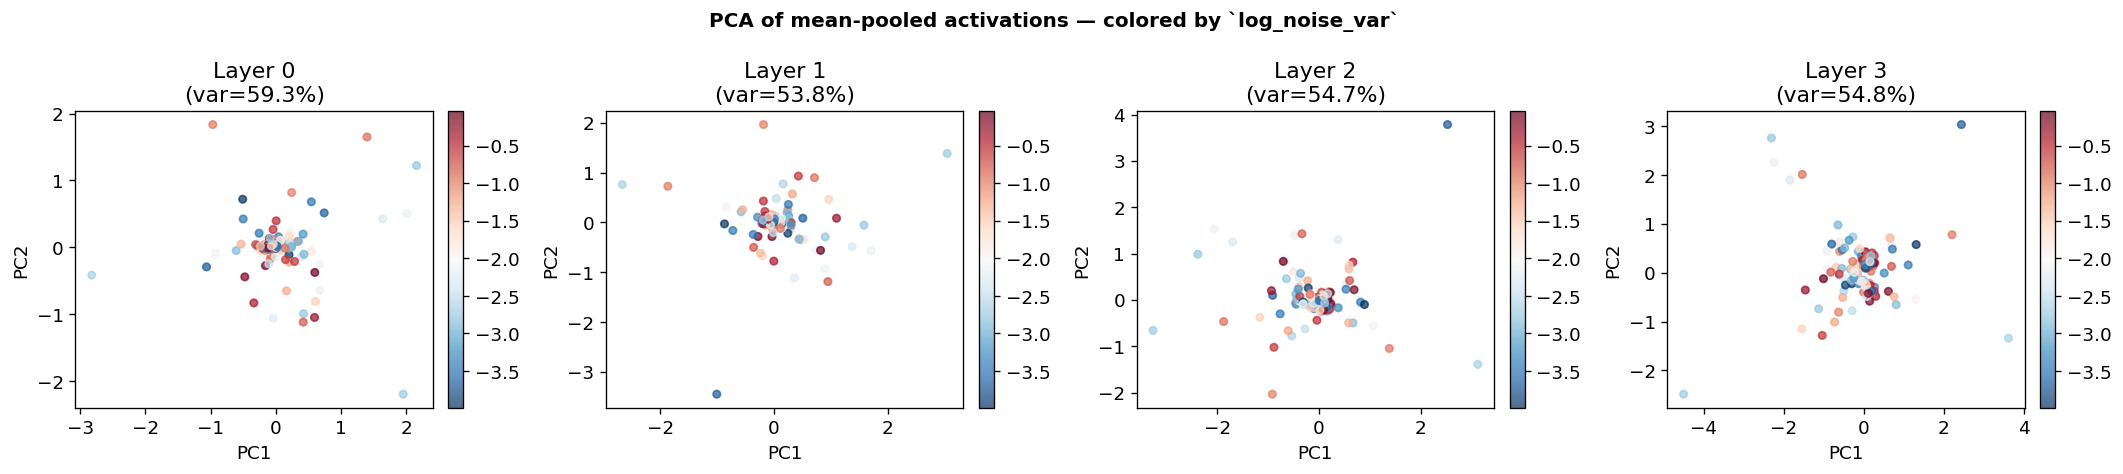

In [8]:
if _HAVE_MODELS:
    from matplotlib.cm import get_cmap

    pca_features = ['slope', 'period_idx', 'log_noise_var']
    pca_layers_to_show = list(range(min(num_layers, 4)))  # first 4 layers

    for color_feature in pca_features:
        labels = pca_dataset[color_feature]
        is_categorical = color_feature in CLASSIFICATION_FEATURES

        fig, axes = plt.subplots(1, len(pca_layers_to_show),
                                 figsize=(4.5 * len(pca_layers_to_show), 4))
        if len(pca_layers_to_show) == 1:
            axes = [axes]

        for ax, layer_idx in zip(axes, pca_layers_to_show):
            X = pca_acts[layer_idx]  # [n, d_model]
            pca = PCA(n_components=2)
            X_2d = pca.fit_transform(X)

            if is_categorical:
                cmap = get_cmap('tab10')
                unique_labels = np.unique(labels)
                for lbl in unique_labels:
                    mask = labels == lbl
                    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                               c=[cmap(lbl / max(unique_labels, default=1))],
                               label=f'class {lbl}', s=20, alpha=0.7)
            else:
                sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                                cmap='RdBu_r', s=20, alpha=0.7)
                plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)

            var_explained = pca.explained_variance_ratio_.sum()
            ax.set_title(f'Layer {layer_idx}\n(var={var_explained:.1%})')
            ax.set_xlabel('PC1')
            ax.set_ylabel('PC2')

        fig.suptitle(f'PCA of mean-pooled activations — colored by `{color_feature}`',
                     fontsize=12, fontweight='bold')
        if is_categorical:
            axes[0].legend(fontsize=7, ncol=2, loc='best')
        plt.tight_layout()
        plt.show()

## Interpretation notes

When using real checkpoints, look for:

- **Early emergence**: features that appear in layers 0–2 are likely encoded by the patch embedding or first few attention heads
- **Encoder vs decoder gap**: the encoder (moiraie) having higher R² at earlier layers would support the hypothesis that bidirectional attention forces earlier feature learning
- **Phase components**: `phase_cos` and `phase_sin` probe the same underlying circular label — if one is probed well but not the other, check the FFT-based label generator
- **Period classification**: `period_idx` accuracy well above the 0.125 chance level indicates the residual stream encodes dominant frequency